<a href="https://colab.research.google.com/github/redrosesarecool/staz/blob/main/krzywa_rotacji.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Unsupervised learning (e.g., DBSCAN, HDBSCAN) to detect distinct kinematic groups, possibly separating gas clouds from different stellar populations automatically.

# Dane

In [ ]:
file_path = "/content/drive/My Drive/r_v_montecarlo.dat"
df_all = pd.read_csv(file_path, delim_whitespace=True)
print(df_all.head())

         R          V
0  2.16208  205.52478
1  2.30257  200.57954
2  2.44236  196.41595
3  2.58141  197.63277
4  2.71967  197.12877


/tmp/ipython-input-1265331101.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_all = pd.read_csv(file_path, delim_whitespace=True)


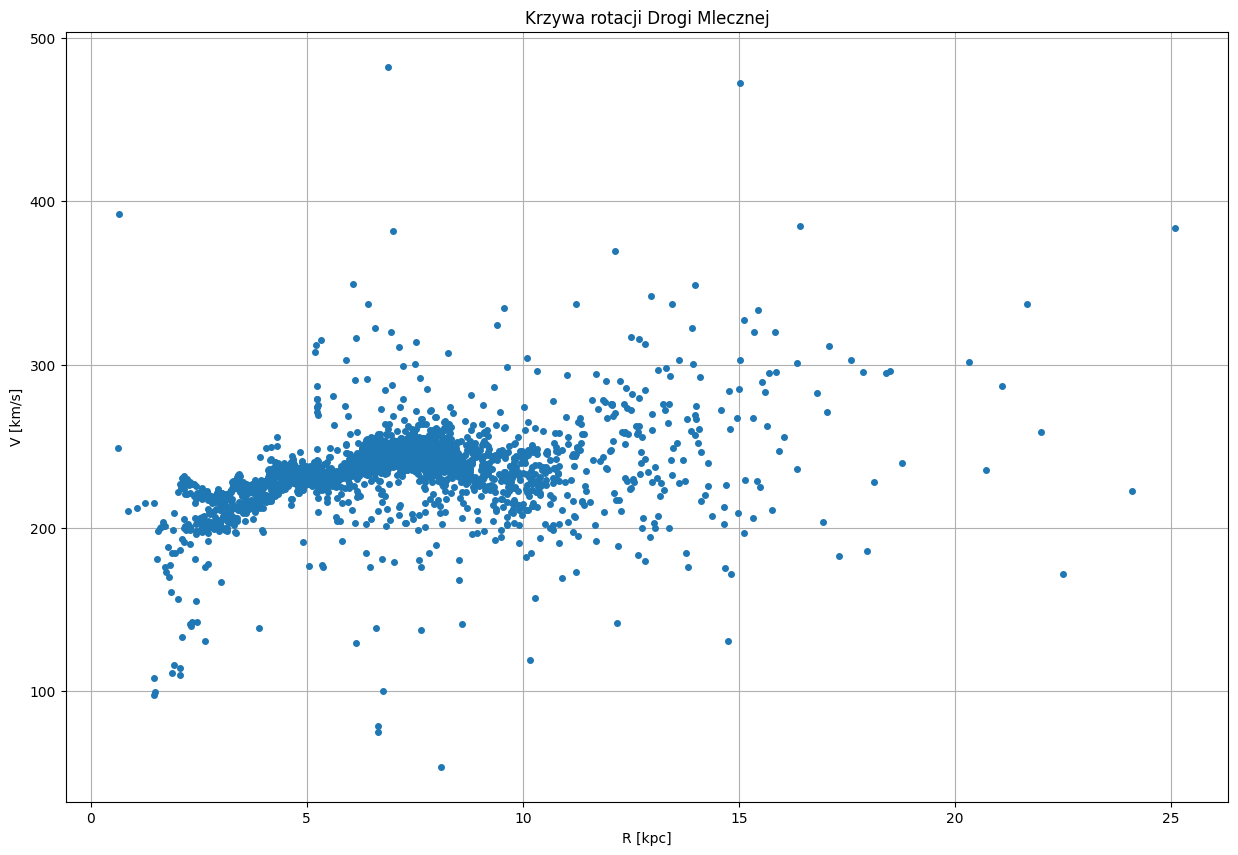

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# wykres R vs V
plt.figure(figsize=(15,10))
plt.plot(df_all["R"], df_all["V"], 'o', markersize=4)
plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Krzywa rotacji Drogi Mlecznej")
plt.grid(True)
plt.show()

# DBSCAN w 2D

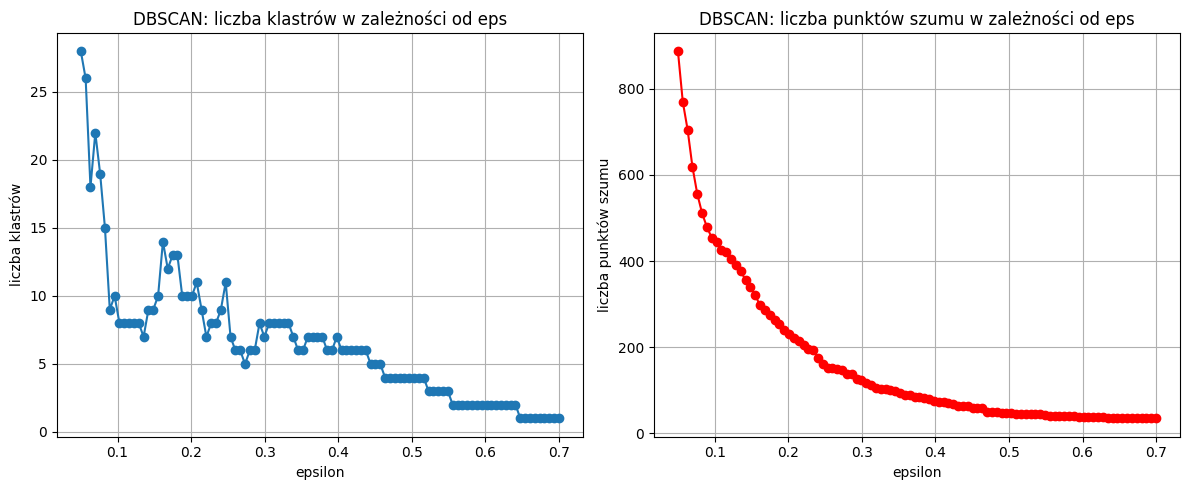

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# skalowanie danych
X = df_all[["R", "V"]].values
X_scaled = StandardScaler().fit_transform(X)

# parametry
eps_values = np.linspace(0.05, 0.7, 100)  # 100 kroków od 0.05 do 0.7
min_samples = 5

# listy do przechowywania wyników
n_clusters_list = []
n_noise_list = []

# pętla po epsilon
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
    labels = db.labels_

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    n_clusters_list.append(n_clusters)
    n_noise_list.append(n_noise)

# wykres
plt.figure(figsize=(12,5))

# liczba klastrów
plt.subplot(1,2,1)
plt.plot(eps_values, n_clusters_list, marker="o")
plt.xlabel("epsilon")
plt.ylabel("liczba klastrów")
plt.title("DBSCAN: liczba klastrów w zależności od eps")
plt.grid(True)

# liczba punktów szumu
plt.subplot(1,2,2)
plt.plot(eps_values, n_noise_list, marker="o", color="red")
plt.xlabel("epsilon")
plt.ylabel("liczba punktów szumu")
plt.title("DBSCAN: liczba punktów szumu w zależności od eps")
plt.grid(True)

plt.tight_layout()
plt.show()

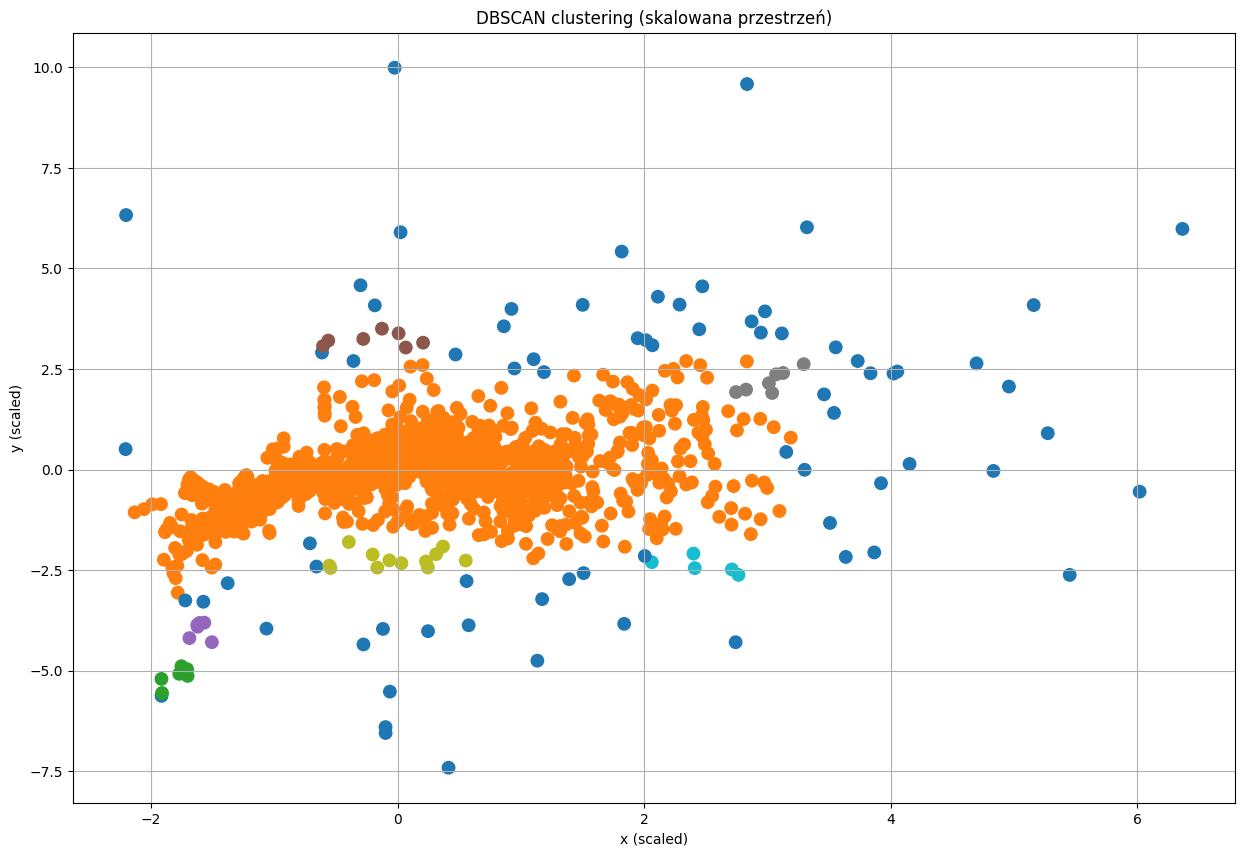

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X = df_all[["R", "V"]].values
X_scaled = StandardScaler().fit_transform(X)

# DBSCAN
db = DBSCAN(eps=0.4, min_samples=5).fit(X_scaled)

# etykiety klastrów
labels = db.labels_
df_all["cluster"] = labels

# wykres
plt.figure(figsize=(15,10))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df_all["cluster"], cmap="tab10", s=80)
plt.xlabel("x (scaled)")
plt.ylabel("y (scaled)")
plt.title("DBSCAN clustering (skalowana przestrzeń)")
plt.grid(True)
plt.show()

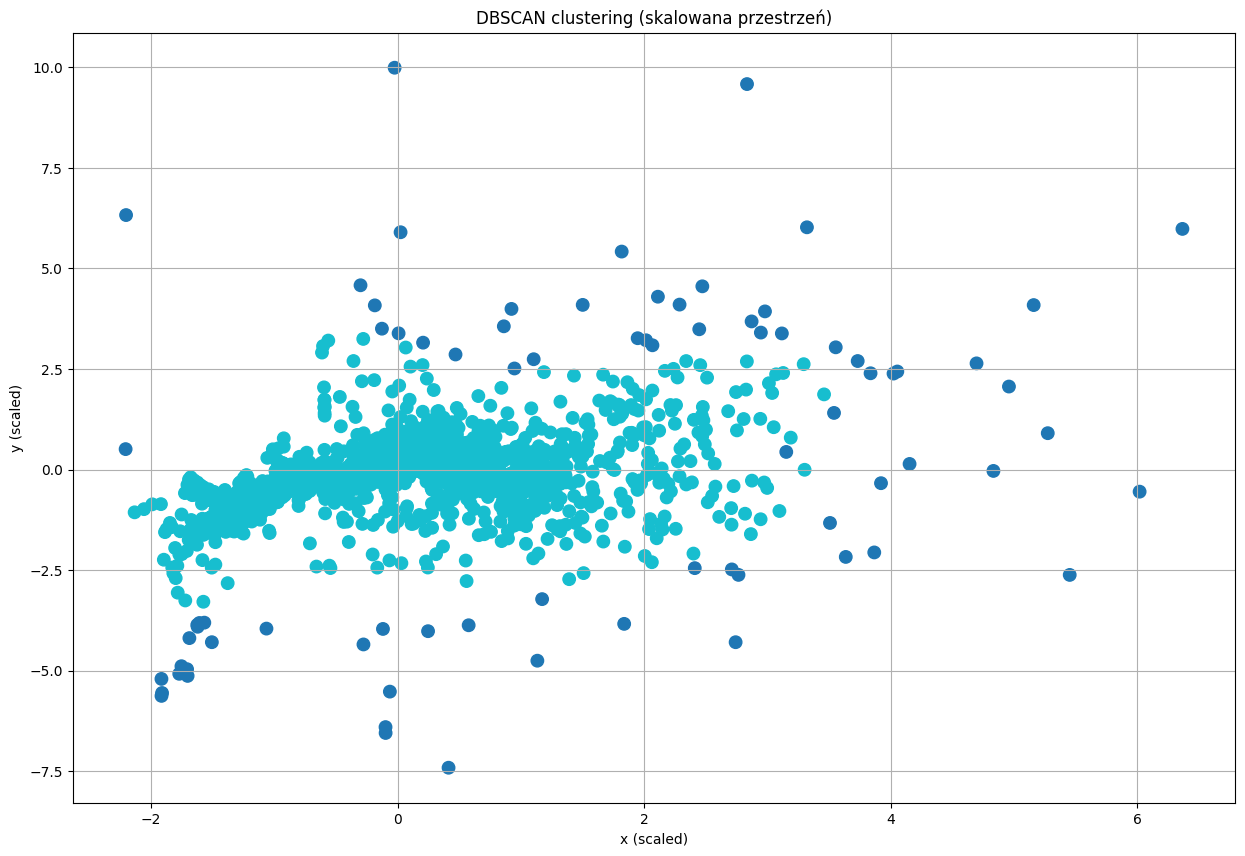

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X = df_all[["R", "V"]].values
X_scaled = StandardScaler().fit_transform(X)

# DBSCAN
db = DBSCAN(eps=0.6, min_samples=10).fit(X_scaled)

# etykiety klastrów
labels = db.labels_
df_all["cluster"] = labels

# wykres
plt.figure(figsize=(15,10))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df_all["cluster"], cmap="tab10", s=80)
plt.xlabel("x (scaled)")
plt.ylabel("y (scaled)")
plt.title("DBSCAN clustering (skalowana przestrzeń)")
plt.grid(True)
plt.show()

# Krzywa rotacji gwiazd

In [ ]:
file_path = "/content/drive/My Drive/r_v_montecarlo-gwiazdy.dat"
df_stars = pd.read_csv(file_path, delim_whitespace=True)
print(df_stars.head())

/tmp/ipython-input-1364008935.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_stars = pd.read_csv(file_path, delim_whitespace=True)


          R          V
0   9.26153  226.40205
1   9.04285  230.36369
2   9.97287  247.06935
3  10.12874  265.07508
4   9.72798  228.31482


Cel: oddzielić różowe od niebieskich

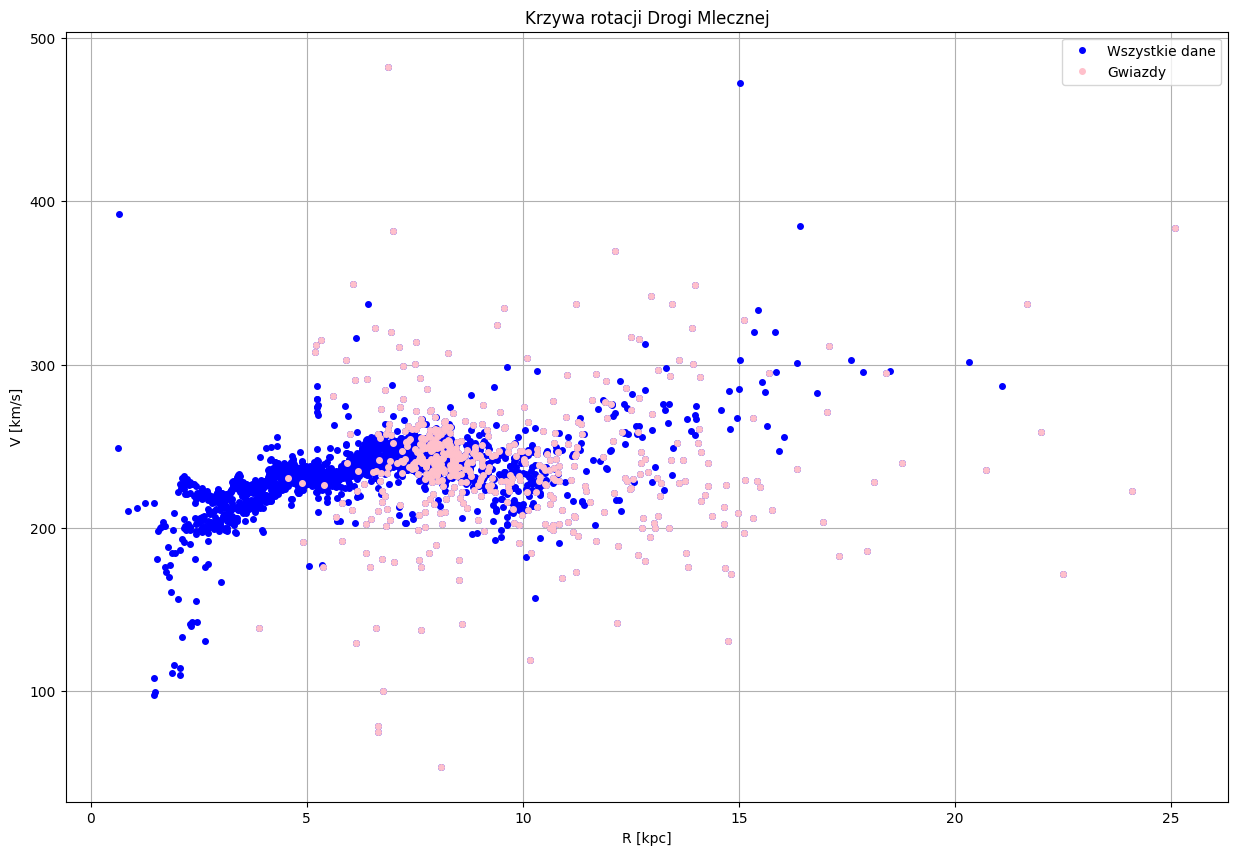

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# wykres z dwoma zestawami danych
plt.figure(figsize=(15,10))

# wszystkie dane
plt.plot(df_all["R"], df_all["V"], 'o', markersize=4, color="blue", label="Wszystkie dane")

# dane rotacji gwiazd
plt.plot(df_stars["R"], df_stars["V"], 'o', markersize=4, color="pink", label="Gwiazdy")

plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Krzywa rotacji Drogi Mlecznej")
plt.grid(True)
plt.legend()
plt.show()


# DBSCAN w 3D

In [ ]:
import pandas as pd

file_path = "/content/drive/My Drive/r_v_z.dat"
df_rvz = pd.read_csv(file_path, delim_whitespace=True)
print(df_rvz.head())

/tmp/ipython-input-3066409719.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_rvz = pd.read_csv(file_path, delim_whitespace=True)


         R          V    z
0  2.15659  205.46459  0.0
1  2.29672  200.51650  0.0
2  2.43616  196.35007  0.0
3  2.57486  197.56407  0.0
4  2.71277  197.05728  0.0


In [ ]:
import pandas as pd
import plotly.express as px
from google.colab import drive

# wykres 3D

fig = px.scatter_3d(
    df_rvz,
    x="R",
    y="V",
    z="z",
    color=None,
    size_max=5,
    opacity=0.6,
    labels={"R":"R [kpc]", "V":"vRt [km/s]", "z":"z [kpc]"},
    title="Wykres 3D: R, V, z"
)

fig.update_layout(
    scene=dict(
        xaxis_title='R [kpc]',
        yaxis_title='vRt [km/s]',
        zaxis_title='z [kpc]',
        aspectmode='manual',
        aspectratio=dict(x=2, y=2, z=0.5)  # proporcje osi
    ),
    width=1000,
    height=700
)

fig.show()

In [ ]:
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# macierz cech 3D
X = df_rvz[["R", "V", "z"]].values
X_scaled = StandardScaler().fit_transform(X)

# DBSCAN
db = DBSCAN(eps=0.065, min_samples=20).fit(X_scaled)
labels = db.labels_
df_rvz["cluster"] = labels.astype(str)

df_rvz["populacja"] = df_rvz["z"].apply(lambda z: "gaz" if abs(z) < 0.065 else "gwiazdy")
print(df_rvz["populacja"].value_counts())

# wykres 3D
fig = px.scatter_3d(
    df_rvz,
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    z=X_scaled[:,2],
    color="populacja",
    symbol="populacja",
    labels={"x":"R (scaled)", "y":"V (scaled)", "z":"z (scaled)"},
    title="DBSCAN clustering w 3D (R, V, z)",
    opacity=0.7
)

fig.update_layout(
    scene=dict(
        xaxis_title='R [kpc]',
        yaxis_title='vRt [km/s]',
        zaxis_title='z [kpc]',
        aspectmode='manual',
        aspectratio=dict(x=2, y=2, z=0.5)  # proporcje osi
    ),
    width=1000,
    height=700
)
fig.show()

print(df_rvz["cluster"].value_counts())

populacja
gaz        2287
gwiazdy     518
Name: count, dtype: int64


cluster
-1    1727
1      439
6      221
0      141
3       92
2       89
4       48
5       48
Name: count, dtype: int64


In [ ]:
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go

# DBSCAN
X = df_rvz[["R", "V", "z"]].values
X_scaled = StandardScaler().fit_transform(X)

db = DBSCAN(eps=0.066, min_samples=20).fit(X_scaled)
labels = db.labels_
df_rvz["cluster"] = labels.astype(str)

df_rvz["populacja"] = df_rvz["z"].apply(lambda z: "gaz" if abs(z) < 0.066 else "gwiazdy")
print(df_rvz["populacja"].value_counts())

# wykres
fig = px.scatter_3d(
    df_rvz,
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    z=X_scaled[:,2],
    color="populacja",
    symbol="populacja",
    labels={"x":"R (scaled)", "y":"V (scaled)", "z":"z (scaled)"},
    title="DBSCAN clustering w 3D (R, V, z)",
    opacity=0.7
)

# dane gwiazd (wiadomo z danych)
subset = df_rvz.iloc[2217:2723]

# ile punktów z subset to gwiazdy
subset_stars = subset[subset["populacja"] == "gwiazdy"]

print(f"Liczba punktów w podzbiorze: {subset.shape[0]}")
print(f"Liczba punktów gwiazd w podzbiorze: {subset_stars.shape[0]}")
print(f"Udział gwiazd w podzbiorze: {subset_stars.shape[0]/subset.shape[0]*100:.2f}%")


# wykres z danymi, które znamy
fig.add_trace(go.Scatter3d(
    x=(subset[["R", "V", "z"]].values[:,0] - X[:,0].mean()) / X[:,0].std(),  # standaryzacja jak X_scaled
    y=(subset[["R", "V", "z"]].values[:,1] - X[:,1].mean()) / X[:,1].std(),
    z=(subset[["R", "V", "z"]].values[:,2] - X[:,2].mean()) / X[:,2].std(),
    mode="markers",
    marker=dict(size=5, color="pink", symbol="circle"),
    name="Wiersze 2218–2723"
))

fig.update_layout(
    scene=dict(
        xaxis_title='R [scaled]',
        yaxis_title='V [scaled]',
        zaxis_title='z [scaled]',
        aspectmode='manual',
        aspectratio=dict(x=2, y=2, z=0.5)
    ),
    width=1000,
    height=700
)

fig.show()

print(df_rvz["cluster"].value_counts())

populacja
gaz        2296
gwiazdy     509
Name: count, dtype: int64
Liczba punktów w podzbiorze: 506
Liczba punktów gwiazd w podzbiorze: 293
Udział gwiazd w podzbiorze: 57.91%


cluster
-1    1715
1      447
6      221
0      141
3       92
2       91
5       50
4       48
Name: count, dtype: int64


In [ ]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X = df_rvz[["R", "V", "z"]].values
X_scaled = StandardScaler().fit_transform(X)

# podzbiór gwiazd "prawdziwych"
subset = df_rvz.iloc[2217:2723].copy()
true_idx = set(subset.index)  # indeksy globalne

best_score = -1
best_params = None

for eps in np.linspace(0.01, 0.1, 100):
    for min_samples in [5, 10, 15, 20, 30]:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
        labels = db.labels_

        df_rvz["cluster_tmp"] = labels

        # zbiór punktów oznaczonych jako szum
        noise_idx = set(df_rvz.index[df_rvz["cluster_tmp"] == -1])

        # prawdziwie pozytywne = przecięcie
        TP = len(noise_idx & true_idx)
        # fałszywie pozytywne = dodatkowe szumy, które nie są w Twoim zbiorze
        FP = len(noise_idx - true_idx)
        # fałszywie negatywne = gwiazdy z Twojego zbioru, które nie weszły do szumu
        FN = len(true_idx - noise_idx)

        # metryki
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision+recall) > 0 else 0

        if f1 > best_score:
            best_score = f1
            best_params = (eps, min_samples, TP, FP, FN, precision, recall)

print(f"✅ Najlepsze parametry: eps={best_params[0]:.3f}, min_samples={best_params[1]}")
print(f"   Pokrycie (recall): {best_params[6]*100:.1f}%")
print(f"   Czystość (precision): {best_params[5]*100:.1f}%")
print(f"   F1-score: {best_score:.3f}")
print(f"   TP={best_params[2]}, FP={best_params[3]}, FN={best_params[4]}")

✅ Najlepsze parametry: eps=0.091, min_samples=5
   Pokrycie (recall): 92.9%
   Czystość (precision): 44.1%
   F1-score: 0.598
   TP=470, FP=596, FN=36


In [ ]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X = df_rvz[["R", "V", "z"]].values
X_scaled = StandardScaler().fit_transform(X)

# podzbiór gwiazd "prawdziwych"
subset = df_rvz.iloc[2217:2723].copy()
true_idx = subset.index  # indeksy globalne

best_score = -1
best_params = None

# iteracje po eps i min_samples
for eps in np.linspace(0.01, 0.1, 100):         # zakres eps do sprawdzenia
    for min_samples in [5, 10, 15, 20, 30]:    # różne min_samples
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
        labels = db.labels_

        df_rvz["cluster_tmp"] = labels

        # sprawdź ile punktów w subset ma label == -1 (gwiazdy)
        subset_clusters = df_rvz.loc[true_idx, "cluster_tmp"]
        score = np.sum(subset_clusters == -1)

        if score > best_score:
            best_score = score
            best_params = (eps, min_samples)

print(f"✅ Najlepsze parametry: eps={best_params[0]:.3f}, min_samples={best_params[1]} "
      f"(gwiazd w szumie: {best_score}/{len(true_idx)})")

✅ Najlepsze parametry: eps=0.010, min_samples=5 (gwiazd w szumie: 506/506)


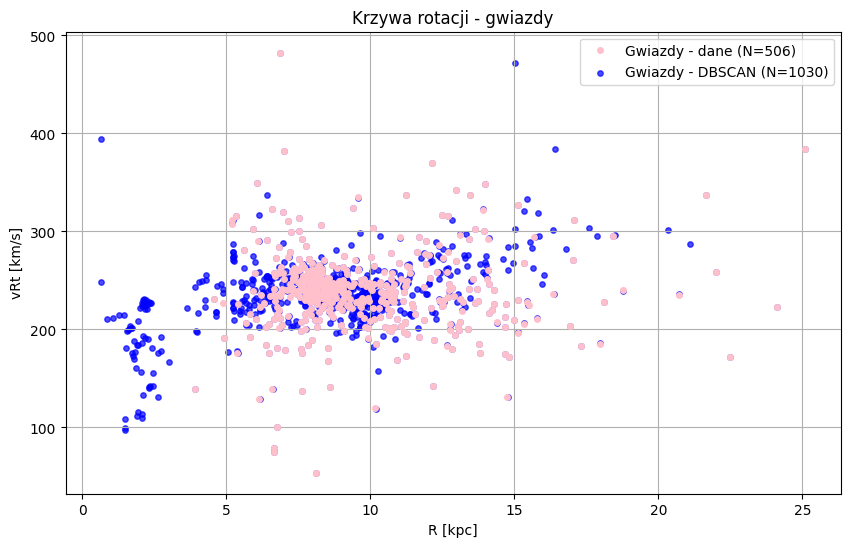

In [ ]:
import matplotlib.pyplot as plt

# tylko gwiazdy
stars = df_rvz[df_rvz["populacja"] == "gwiazdy"]

# liczebność zbiorów
n_stars_dane = df_stars.shape[0]
n_stars_dbscan = stars.shape[0]

plt.figure(figsize=(10,6))

# wykres z xdanych
plt.plot(df_stars["R"], df_stars["V"], 'o', markersize=4, color="pink", label=f"Gwiazdy - dane (N={n_stars_dane})")

# wykres z DBSCAN
plt.scatter(stars["R"], stars["V"], s=15, c="blue", alpha=0.7, label=f"Gwiazdy - DBSCAN (N={n_stars_dbscan})")

plt.xlabel("R [kpc]")
plt.ylabel("vRt [km/s]")
plt.title("Krzywa rotacji - gwiazdy")
plt.legend()
plt.grid(True)
plt.show()

# DBSCAN w 4D